# Database comparison: taxonomic breadth per domain × rank

For each profiling tool's default DB (and the unified DB), count distinct
phylum / genus / species per domain (Bacteria / Archaea / Viruses / Fungi / Other).
Outputs land under `bakeoff/results/database-comparison/` to match sibling analyses.


## Configuration

In [2]:
from pathlib import Path
import sys

# Make utils.* importable when running from anywhere under bakeoff/
_HERE = Path.cwd()
for _cand in (_HERE / 'scripts' / 'analysis', _HERE, _HERE / 'bakeoff' / 'scripts' / 'analysis'):
    if (_cand / 'utils' / '__init__.py').exists() and str(_cand) not in sys.path:
        sys.path.insert(0, str(_cand))
        break
from utils.results import save_csv, save_fig
import gzip

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
# ---- Inputs ----
REF_DB = Path("/home/Users/pacbio_bakeoff/data/ref_db")

UNIFIED_DB_TSV   = REF_DB / "refseq03032025/refseq_030325_lineage.tsv"
UNIFIED_NODES    = REF_DB / "refseq03032025/taxdump/nodes.dmp"

K2_SEQMAP        = REF_DB / "default_db/k2_default/seqid2taxid.map"
K2_TAXONOMY      = REF_DB / "default_db/k2_default/ktaxonomy.tsv"

CF_SIZETABLE     = REF_DB / "default_db/cf_default/cf_default_size_table.txt"
CF_TAXTREE       = REF_DB / "default_db/cf_default/cf_default_inspect.txt"

CFER_SIZETABLE   = REF_DB / "default_db/cfer_default/cfer_default_size_table.txt"
CFER_TAXTREE     = REF_DB / "default_db/cfer_default/cfer_default_inspect.txt"

SOURMASH_LINEAGE = REF_DB / "default_db/sm_default/sourmash_lineage_default_merged.csv"

GANON2_LINEAGE   = (
    REF_DB / "default_db/ganon2_default/ganon2_default_abfv_rs_cg_files"
           / "2025-11-15_11-41-36/ganon_refseq_111525_lineage.tsv"
)

SYLPH_FUNGI      = REF_DB / "default_db/sylph_tax/fungi_refseq_2024-07-25_metadata.tsv.gz"
SYLPH_VIRAL      = REF_DB / "default_db/sylph_tax/IMGVR_4.1_metadata.tsv.gz"

# Outputs (no timestamp: this notebook compares static reference DBs)
SAVE       = True
OUTDIR     = Path("/home/Users/pacbio_bakeoff/bakeoff/results/database-comparison")
TABLE_DIR  = OUTDIR / "tables"
FIGURE_DIR = OUTDIR / "figures"

# ---- Taxonomy constants ----
TAXID_BACTERIA = 2
TAXID_ARCHAEA  = 2157
TAXID_VIRUSES  = 10239
TAXID_FUNGI    = 4751

DOMAINS  = ["Bacteria", "Archaea", "Viruses", "Fungi", "Other"]
RANKS    = ["phylum", "genus", "species"]
# Manuscript order
DB_ORDER = [
    "Unified",
    "Kraken2_default",
    "Centrifuge_default",
    "Centrifuger_default",
    "Ganon2_default",
    "Sourmash_default",
    "Sylph_default",
]


## Generic taxonomy helpers

In [4]:
def make_taxonomy_helpers(parent_map, rank_map):
    """Build lineage / first-ancestor / domain helpers from {taxid: parent} + {taxid: rank}."""
    def lineage(taxid):
        out, t = [], taxid
        while True:
            out.append(t)
            p = parent_map.get(t)
            if p is None or p == t:
                return out
            t = p

    def first_ancestor(taxid, target_rank):
        for t in lineage(taxid):
            if rank_map.get(t) == target_rank:
                return t
        return None

    def domain(taxid):
        if taxid is None:
            return "Other"
        lin = lineage(taxid)
        if TAXID_FUNGI    in lin: return "Fungi"
        if TAXID_BACTERIA in lin: return "Bacteria"
        if TAXID_ARCHAEA  in lin: return "Archaea"
        if TAXID_VIRUSES  in lin: return "Viruses"
        return "Other"

    return lineage, first_ancestor, domain


def summarise_taxid_breadth(db_label, taxids, first_ancestor, domain_of):
    """For each rank, count distinct ancestor taxids per domain."""
    base = pd.Series(sorted({int(t) for t in taxids}))
    rows = []
    for rank in RANKS:
        ancestors = (
            base.map(lambda t, r=rank: first_ancestor(t, r))
                .dropna().astype(int).unique()
        )
        if len(ancestors) == 0:
            continue
        dom = pd.Series([domain_of(t) for t in ancestors])
        for d, n in dom.value_counts().items():
            rows.append({"db": db_label, "domain": d, "rank": rank, "n_taxa": int(n)})
    return pd.DataFrame(rows)


def load_pipe_taxonomy(path, min_fields=3, want_name=False):
    """Parse '|'-delimited taxonomy files (nodes.dmp, ktaxonomy.tsv, centrifuge-inspect).
    Returns (parent_map, rank_map[, name_map]) using the first 3 (or 4) tokens after split."""
    parent, rank, name = {}, {}, {}
    with path.open() as f:
        for line in f:
            parts = [p.strip() for p in line.split("|")]
            if len(parts) < min_fields:
                continue
            taxid = int(parts[0])
            parent[taxid] = int(parts[1])
            rank[taxid]   = parts[2]
            if want_name and len(parts) >= 5:
                name[taxid] = parts[4]
    return (parent, rank, name) if want_name else (parent, rank)


## Per-DB breadth tables

### Unified DB

In [5]:
unified_parent, unified_rank = load_pipe_taxonomy(UNIFIED_NODES)
_, unified_first_anc, unified_domain = make_taxonomy_helpers(unified_parent, unified_rank)

unified_df = pd.read_csv(
    UNIFIED_DB_TSV, sep="\t",
    dtype={"species_taxid": "Int64", "genus_taxid": "Int64", "phylum": str},
)
unified_taxids = unified_df["species_taxid"].dropna().astype(int).unique()

unified_breadth = summarise_taxid_breadth(
    "Unified", unified_taxids, unified_first_anc, unified_domain,
)
unified_breadth


,db,domain,rank,n_taxa
0,Unified,Bacteria,phylum,52
1,Unified,Viruses,phylum,17
2,Unified,Archaea,phylum,8
3,Unified,Fungi,phylum,4
4,Unified,Viruses,genus,2759
5,Unified,Bacteria,genus,2194
6,Unified,Archaea,genus,160
7,Unified,Fungi,genus,69
8,Unified,Viruses,species,13965
9,Unified,Bacteria,species,12994


### Kraken2 default

In [6]:
# Kraken rank codes -> conceptual ranks we count
K2_RANKS = {"S": "species", "G": "genus", "P": "phylum"}

k2_parent, k2_rank_code, k2_name = load_pipe_taxonomy(K2_TAXONOMY, min_fields=5, want_name=True)
k2_rank = {t: K2_RANKS[c] for t, c in k2_rank_code.items() if c in K2_RANKS}

_, k2_first_anc, k2_domain = make_taxonomy_helpers(k2_parent, k2_rank)

k2_taxids = pd.read_csv(K2_SEQMAP, sep="\t", header=None,
                        names=["seqid", "taxid"])["taxid"].astype(int).unique()

k2_breadth = summarise_taxid_breadth(
    "Kraken2_default", k2_taxids, k2_first_anc, k2_domain,
)
k2_breadth


,db,domain,rank,n_taxa
0,Kraken2_default,Bacteria,phylum,52
1,Kraken2_default,Viruses,phylum,18
2,Kraken2_default,Archaea,phylum,8
3,Kraken2_default,Other,phylum,5
4,Kraken2_default,Fungi,phylum,1
5,Kraken2_default,Viruses,genus,2759
6,Kraken2_default,Bacteria,genus,2261
7,Kraken2_default,Archaea,genus,161
8,Kraken2_default,Other,genus,6
9,Kraken2_default,Fungi,genus,1


### Centrifuge / Centrifuger default

In [7]:
def load_size_table(path):
    df = pd.read_csv(path, sep="\t", header=None, names=["taxid", "length"])
    return df.loc[df["length"] > 0, "taxid"].astype(int).unique()


cf_parent,   cf_rank   = load_pipe_taxonomy(CF_TAXTREE)
cfer_parent, cfer_rank = load_pipe_taxonomy(CFER_TAXTREE)

_, cf_first_anc,   cf_domain   = make_taxonomy_helpers(cf_parent,   cf_rank)
_, cfer_first_anc, cfer_domain = make_taxonomy_helpers(cfer_parent, cfer_rank)

cf_breadth = summarise_taxid_breadth(
    "Centrifuge_default",  load_size_table(CF_SIZETABLE),   cf_first_anc,   cf_domain,
)
cfer_breadth = summarise_taxid_breadth(
    "Centrifuger_default", load_size_table(CFER_SIZETABLE), cfer_first_anc, cfer_domain,
)
pd.concat([cf_breadth.head(), cfer_breadth.head()])


,db,domain,rank,n_taxa
0,Centrifuge_default,Bacteria,phylum,38
1,Centrifuge_default,Archaea,phylum,5
2,Centrifuge_default,Other,phylum,1
3,Centrifuge_default,Viruses,phylum,1
4,Centrifuge_default,Bacteria,genus,1252
0,Centrifuger_default,Bacteria,phylum,46
1,Centrifuger_default,Viruses,phylum,17
2,Centrifuger_default,Archaea,phylum,9
3,Centrifuger_default,Other,phylum,1
4,Centrifuger_default,Viruses,genus,2546


### Ganon2 default

In [8]:
def summarise_ganon2_breadth(path, db_label="Ganon2_default"):
    df = pd.read_csv(path, sep="\t")
    cols = {"phylum": "phylum_taxid", "genus": "genus_taxid", "species": "species_taxid_lineage"}
    rows = []
    for rank, col in cols.items():
        sub = df[[col, "domain_label"]].dropna(subset=[col]).copy()
        sub[col] = sub[col].astype(int)
        for dom, n in sub.groupby("domain_label")[col].nunique().items():
            rows.append({"db": db_label, "domain": dom, "rank": rank, "n_taxa": int(n)})
    return pd.DataFrame(rows)


ganon2_breadth = summarise_ganon2_breadth(GANON2_LINEAGE)
ganon2_breadth


,db,domain,rank,n_taxa
0,Ganon2_default,Archaea,phylum,8
1,Ganon2_default,Bacteria,phylum,52
2,Ganon2_default,Fungi,phylum,3
3,Ganon2_default,Viruses,phylum,19
4,Ganon2_default,Archaea,genus,159
5,Ganon2_default,Bacteria,genus,2235
6,Ganon2_default,Fungi,genus,42
7,Ganon2_default,Viruses,genus,2907
8,Ganon2_default,Archaea,species,510
9,Ganon2_default,Bacteria,species,13419


### Sourmash default

In [9]:
FUNGI_PHYLUM_SUFFIXES = ("mycota",)
FUNGI_PHYLUM_KEYWORDS = ("fungi", "microsporidia")


def sourmash_domain(row):
    sk = str(row.get("superkingdom", "")).strip()
    if sk in {"Bacteria", "Archaea", "Viruses"}:
        return sk
    ph = str(row.get("phylum", "")).strip().lower()
    if ph.endswith(FUNGI_PHYLUM_SUFFIXES) or any(k in ph for k in FUNGI_PHYLUM_KEYWORDS):
        return "Fungi"
    return "Other"


def summarise_sourmash_breadth(df, db_label="Sourmash_default"):
    df = df.copy()
    df["domain"] = df.apply(sourmash_domain, axis=1)
    rows = []
    for rank in RANKS:
        counts = df.dropna(subset=[rank]).groupby("domain")[rank].nunique()
        for dom, n in counts.items():
            rows.append({"db": db_label, "domain": dom, "rank": rank, "n_taxa": int(n)})
    return pd.DataFrame(rows), df


sourmash_lineage = pd.read_csv(SOURMASH_LINEAGE)
sourmash_breadth, sourmash_with_domain = summarise_sourmash_breadth(sourmash_lineage)
sourmash_breadth


/tmp/ipykernel_3320303/1726694625.py:26: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  sourmash_lineage = pd.read_csv(SOURMASH_LINEAGE)


,db,domain,rank,n_taxa
0,Sourmash_default,Archaea,phylum,36
1,Sourmash_default,Bacteria,phylum,164
2,Sourmash_default,Fungi,phylum,10
3,Sourmash_default,Viruses,phylum,17
4,Sourmash_default,Archaea,genus,217
5,Sourmash_default,Bacteria,genus,3897
6,Sourmash_default,Fungi,genus,960
7,Sourmash_default,Viruses,genus,2169
8,Sourmash_default,Archaea,species,2580
9,Sourmash_default,Bacteria,species,59468


### Sylph default (fungi + viral metadata)

In [10]:
RANK_PREFIX = {"phylum": "p__", "genus": "g__", "species": "s__"}


def _names_for_rank(lineage, prefix):
    if not isinstance(lineage, str):
        return ()
    return tuple(
        p[len(prefix):]
        for p in (s.strip() for s in lineage.split(";"))
        if p.startswith(prefix) and len(p) > len(prefix)
    )


def sylph_lineage_sets(path_gz, has_header):
    """Read a Sylph GTDB-style metadata file; return {rank: set(names)}.
    Lineage is in the 'Taxonomic classification' column if a header exists, else column 2."""
    sets = {r: set() for r in RANKS}
    lineage_col = 1
    with gzip.open(path_gz, "rt") as f:
        if has_header:
            header = f.readline().rstrip("\n").split("\t")
            for i, h in enumerate(header):
                if h.strip() == "Taxonomic classification":
                    lineage_col = i
                    break
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) <= lineage_col:
                continue
            lineage = parts[lineage_col]
            for rank, prefix in RANK_PREFIX.items():
                sets[rank].update(_names_for_rank(lineage, prefix))
    return sets


fungi_sets = sylph_lineage_sets(SYLPH_FUNGI, has_header=False)
viral_sets = sylph_lineage_sets(SYLPH_VIRAL, has_header=True)

# Sylph only covers Fungi + Viruses here; record zero for other domains so the
# matrix has the same shape as the other DBs.
sylph_rows = []
for dom, sets in (("Fungi", fungi_sets), ("Viruses", viral_sets)):
    for rank in RANKS:
        sylph_rows.append({"db": "Sylph_default", "domain": dom, "rank": rank,
                           "n_taxa": len(sets[rank])})
for dom in ("Bacteria", "Archaea", "Other"):
    for rank in RANKS:
        sylph_rows.append({"db": "Sylph_default", "domain": dom, "rank": rank, "n_taxa": 0})

sylph_breadth = pd.DataFrame(sylph_rows)
sylph_breadth


,db,domain,rank,n_taxa
0,Sylph_default,Fungi,phylum,6
1,Sylph_default,Fungi,genus,270
2,Sylph_default,Fungi,species,595
3,Sylph_default,Viruses,phylum,17
4,Sylph_default,Viruses,genus,2116
5,Sylph_default,Viruses,species,4519
6,Sylph_default,Bacteria,phylum,0
7,Sylph_default,Bacteria,genus,0
8,Sylph_default,Bacteria,species,0
9,Sylph_default,Archaea,phylum,0


## Combine and save

In [11]:
breadth_df = pd.concat(
    [unified_breadth, k2_breadth, cf_breadth, cfer_breadth,
     sourmash_breadth, sylph_breadth, ganon2_breadth],
    ignore_index=True,
)
breadth_df["db"]     = pd.Categorical(breadth_df["db"],     categories=DB_ORDER, ordered=True)
breadth_df["rank"]   = pd.Categorical(breadth_df["rank"],   categories=RANKS,    ordered=True)
breadth_df["domain"] = pd.Categorical(breadth_df["domain"], categories=DOMAINS,  ordered=True)
breadth_df = breadth_df.sort_values(["db", "rank", "domain"]).reset_index(drop=True)

save_csv(breadth_df, TABLE_DIR / "taxonomic_breadth_per_db_domain_rank.tsv", SAVE,
         sep="\t", index=False)

matrix = (
    breadth_df
    .pivot_table(index=["db", "rank"], columns="domain",
                 values="n_taxa", fill_value=0, aggfunc="sum")
    .reindex(index=pd.MultiIndex.from_product([DB_ORDER, RANKS]),
             columns=DOMAINS, fill_value=0)
)
save_csv(matrix, TABLE_DIR / "taxonomic_breadth_matrix_all_dbs.tsv", SAVE, sep="\t")
matrix


/tmp/ipykernel_3320303/571724724.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index=["db", "rank"], columns="domain",


domain                       Bacteria  Archaea  Viruses  Fungi  Other
Unified             phylum         52        8       17      4      0
                    genus        2194      160     2759     69      0
                    species     12994      504    13965    129      0
Kraken2_default     phylum         52        8       18      1      5
                    genus        2261      161     2759      1      6
                    species     13841      529    13966      1     27
Centrifuge_default  phylum         38        5        1      0      1
                    genus        1252      110      973      0      1
                    species      4970      264     8647      0      1
Centrifuger_default phylum         46        9       17      0      1
                    genus        1789      142     2546      0      1
                    species      8501      415    13978      0      1
Ganon2_default      phylum         52        8       19      3      0
                    genus        2235      159     2907     42      0
                    species     13419      510    13602     66      0
Sourmash_default    phylum        164       36       17     10      0
                    genus        3897      217     2169    960      0
                    species     59468     2580    23198   3266      5
Sylph_default       phylum          0        0       17      6      0
                    genus           0        0     2116    270      0
                    species         0        0     4519    595      0

## Plots

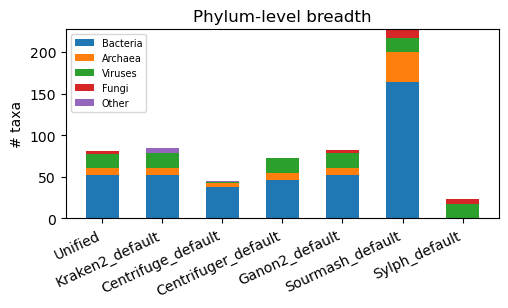

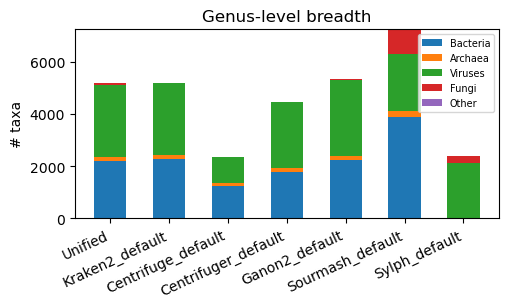

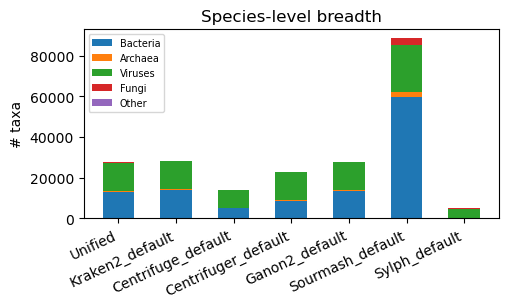

In [12]:
def _stacked_bar(ax, sub, x):
    bottom = np.zeros(len(DB_ORDER))
    for dom in DOMAINS:
        heights = (
            sub[sub["domain"] == dom]
            .set_index("db")["n_taxa"]
            .reindex(DB_ORDER).fillna(0).values
        )
        ax.bar(x, heights, bottom=bottom, width=0.55, label=dom)
        bottom += heights


def plot_breadth_bar(df, rank, outfile=None):
    x = np.arange(len(DB_ORDER))
    fig, ax = plt.subplots(figsize=(5, 3))
    _stacked_bar(ax, df[df["rank"] == rank], x)
    ax.set_xticks(x)
    ax.set_xticklabels(DB_ORDER, rotation=25, ha="right")
    ax.set_ylabel("# taxa")
    ax.set_title(f"{rank.capitalize()}-level breadth")
    ax.legend(fontsize=7)
    plt.tight_layout(pad=0.4)
    if outfile is not None:
        save_fig(fig, outfile, SAVE, dpi=300, bbox_inches="tight")
    plt.show()


for rnk in RANKS:
    plot_breadth_bar(breadth_df, rnk, FIGURE_DIR / f"breadth_{rnk}_all_dbs.png")


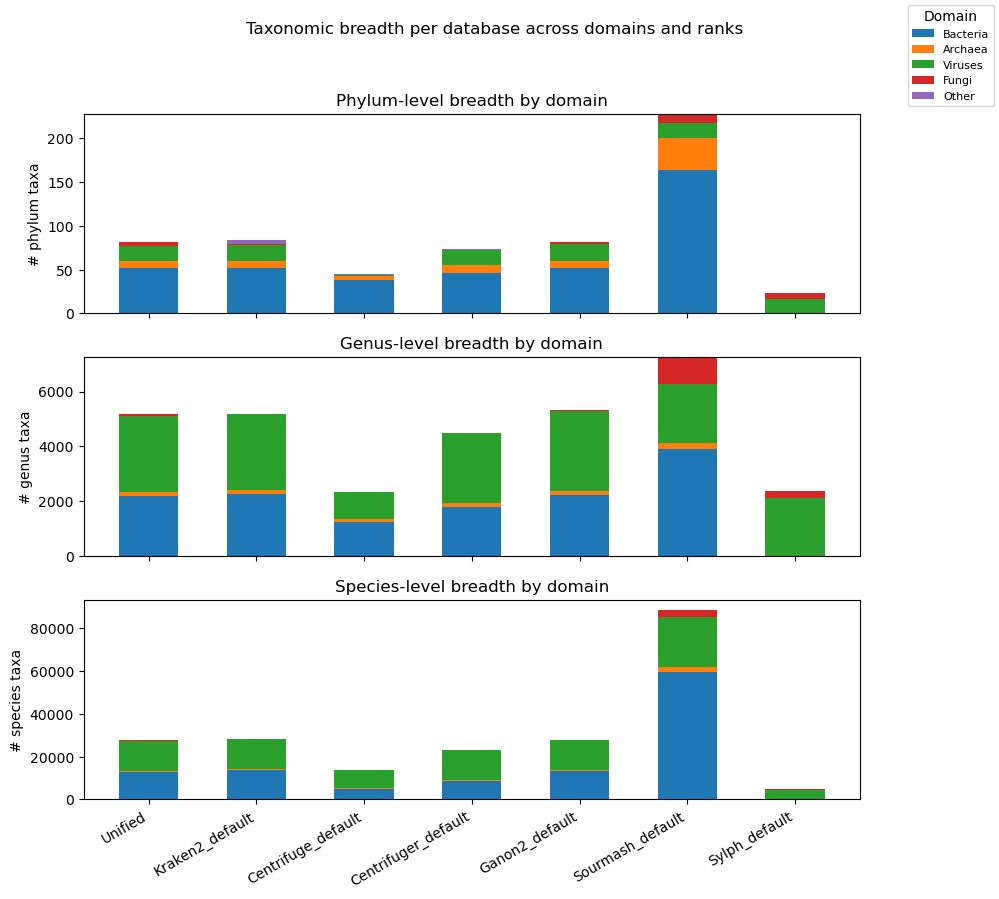

In [13]:
def plot_mosaic_breadth(df, outfile=None):
    x = np.arange(len(DB_ORDER))
    fig, axes = plt.subplots(nrows=len(RANKS), ncols=1, figsize=(10, 9), sharex=True)
    for ax, rank in zip(axes, RANKS):
        _stacked_bar(ax, df[df["rank"] == rank], x)
        ax.set_ylabel(f"# {rank} taxa")
        ax.set_title(f"{rank.capitalize()}-level breadth by domain")
    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(DB_ORDER, rotation=30, ha="right")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Domain", loc="upper right", fontsize=8)
    fig.suptitle("Taxonomic breadth per database across domains and ranks", y=0.98)
    fig.tight_layout(rect=[0.0, 0.0, 0.88, 0.95])
    if outfile is not None:
        save_fig(fig, outfile, SAVE, dpi=300, bbox_inches="tight")
    plt.show()


plot_mosaic_breadth(breadth_df, FIGURE_DIR / "breadth_mosaic_all_dbs.png")


## Inspect "Other" entries

Diagnostic exports for the rows that fall into the catch-all `Other` domain.
Saved under `debug/` so they don't clutter the main results.


In [14]:
DEBUG_DIR = OUTDIR / "debug"
DEBUG_DIR.mkdir(parents=True, exist_ok=True)

# ---- Sourmash: 'Other' species entries ----
sourmash_other = (
    sourmash_with_domain[
        (sourmash_with_domain["domain"] == "Other")
        & sourmash_with_domain["species"].notna()
    ][["ident", "superkingdom", "phylum", "genus", "species"]]
    .drop_duplicates()
    .sort_values("species")
)
save_csv(sourmash_other, DEBUG_DIR / "sourmash_default_other_species.tsv", SAVE,
         sep="\t", index=False)
print(f"Sourmash 'Other' unique species: {sourmash_other['species'].nunique()}")

# ---- Kraken2: 'Other' raw taxids, resolved to species where possible ----
k2_df = pd.DataFrame({"raw_taxid": pd.unique(k2_taxids)})
k2_df["species_taxid"] = k2_df["raw_taxid"].map(
    lambda t: t if k2_rank.get(t) == "species" else k2_first_anc(t, "species")
)
k2_df["domain"] = k2_df.apply(
    lambda r: k2_domain(r["species_taxid"] if pd.notna(r["species_taxid"]) else r["raw_taxid"]),
    axis=1,
)
k2_other = k2_df[k2_df["domain"] == "Other"].copy()
k2_other["species_name"] = k2_other["species_taxid"].map(
    lambda t: k2_name.get(int(t), "") if pd.notna(t) else ""
)
k2_other["raw_name"] = k2_other["raw_taxid"].map(lambda t: k2_name.get(int(t), ""))
save_csv(k2_other, DEBUG_DIR / "kraken2_default_other_taxids.tsv", SAVE,
         sep="\t", index=False)
print(f"Kraken2 'Other' raw taxids: {len(k2_other)} "
      f"(resolved to species: {int(k2_other['species_taxid'].notna().sum())})")


Sourmash 'Other' unique species: 5
Kraken2 'Other' raw taxids: 28 (resolved to species: 27)
